# SVD Time Series Imputation: Uncertainty Estimation Tutorial

This notebook demonstrates **three methods** for estimating uncertainty in imputed time series values:

1. **Monte Carlo** - Fast, constant uncertainty band based on validation
2. **Bootstrap** - Slower, point-wise uncertainty via resampling
3. **Hybrid** - Combines both approaches for best accuracy

## Goals
- Understand how each method works
- Visualize the differences between methods
- Learn when to use each approach
- Apply to real-world time series data

## 1. Setup and Imports

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from svd_imputer import Imputer

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful!")
print(f"SVD Imputer version: 0.1.0")

✓ Imports successful!
SVD Imputer version: 0.1.0


## 2. Create Synthetic Time Series Data

We'll create realistic time series with:
- **Three monitoring sites** (A, B, C) with correlated measurements
- **Seasonal patterns** and random noise
- **Missing values ONLY in Site_C** - all data from May 2020 onwards
- **Sites A and B fully observed** (used as predictors to impute Site_C)

This simulates a common real-world scenario where one sensor fails completely at a point in time, but neighboring sensors continue recording.

In [49]:
# Create date range
dates = pd.date_range('2020-01-01', periods=200, freq='D')
n_points = len(dates)
t = np.arange(n_points)

# Generate three correlated time series with different patterns
series_a = 10 + 3 * np.sin(2 * np.pi * t / 30) + np.random.normal(0, 0.3, n_points)
series_b = 15 + 2 * np.cos(2 * np.pi * t / 45) + 0.5 * series_a + np.random.normal(0, 0.4, n_points)
series_c = 12 + 1.5 * np.sin(2 * np.pi * t / 60) + 0.3 * series_b + np.random.normal(0, 0.35, n_points)

# Create DataFrame
df_complete = pd.DataFrame({
    'Site_A': series_a,
    'Site_B': series_b,
    'Site_C': series_c
}, index=dates)

# Store complete data for comparison
df_truth = df_complete.copy()

# Add missing values ONLY to Site_C (target for imputation)
# Remove all data from May 2020 onwards (simulate sensor failure)
cutoff_date = pd.Timestamp('2020-05-01')
df_complete.loc[df_complete.index >= cutoff_date, 'Site_C'] = np.nan

# Summary
print(f"Time series shape: {df_complete.shape}")
print(f"Date range: {df_complete.index.min()} to {df_complete.index.max()}")
print(f"\nMissing values per series:")
for col in df_complete.columns:
    n_missing = df_complete[col].isna().sum()
    pct = (n_missing / len(df_complete)) * 100
    print(f"  {col}: {n_missing} ({pct:.1f}%)")
    
total_missing = df_complete.isna().sum().sum()
total_values = df_complete.size
print(f"\nTotal missing: {total_missing} / {total_values} ({100*total_missing/total_values:.1f}%)")
print(f"\n⚠️  Only Site_C has missing values")
print(f"    Sites A and B are fully observed and used to impute Site_C")
print(f"    Site_C: All data from {cutoff_date.strftime('%Y-%m-%d')} onwards is missing")

# Verification
assert df_complete['Site_A'].isna().sum() == 0, "ERROR: Site_A has missing values!"
assert df_complete['Site_B'].isna().sum() == 0, "ERROR: Site_B has missing values!"
assert df_complete['Site_C'].isna().sum() > 0, "ERROR: Site_C should have missing values!"
print("\n✓ Verification passed: Only Site_C has missing values")

Time series shape: (200, 3)
Date range: 2020-01-01 00:00:00 to 2020-07-18 00:00:00

Missing values per series:
  Site_A: 0 (0.0%)
  Site_B: 0 (0.0%)
  Site_C: 79 (39.5%)

Total missing: 79 / 600 (13.2%)

⚠️  Only Site_C has missing values
    Sites A and B are fully observed and used to impute Site_C
    Site_C: All data from 2020-05-01 onwards is missing

✓ Verification passed: Only Site_C has missing values


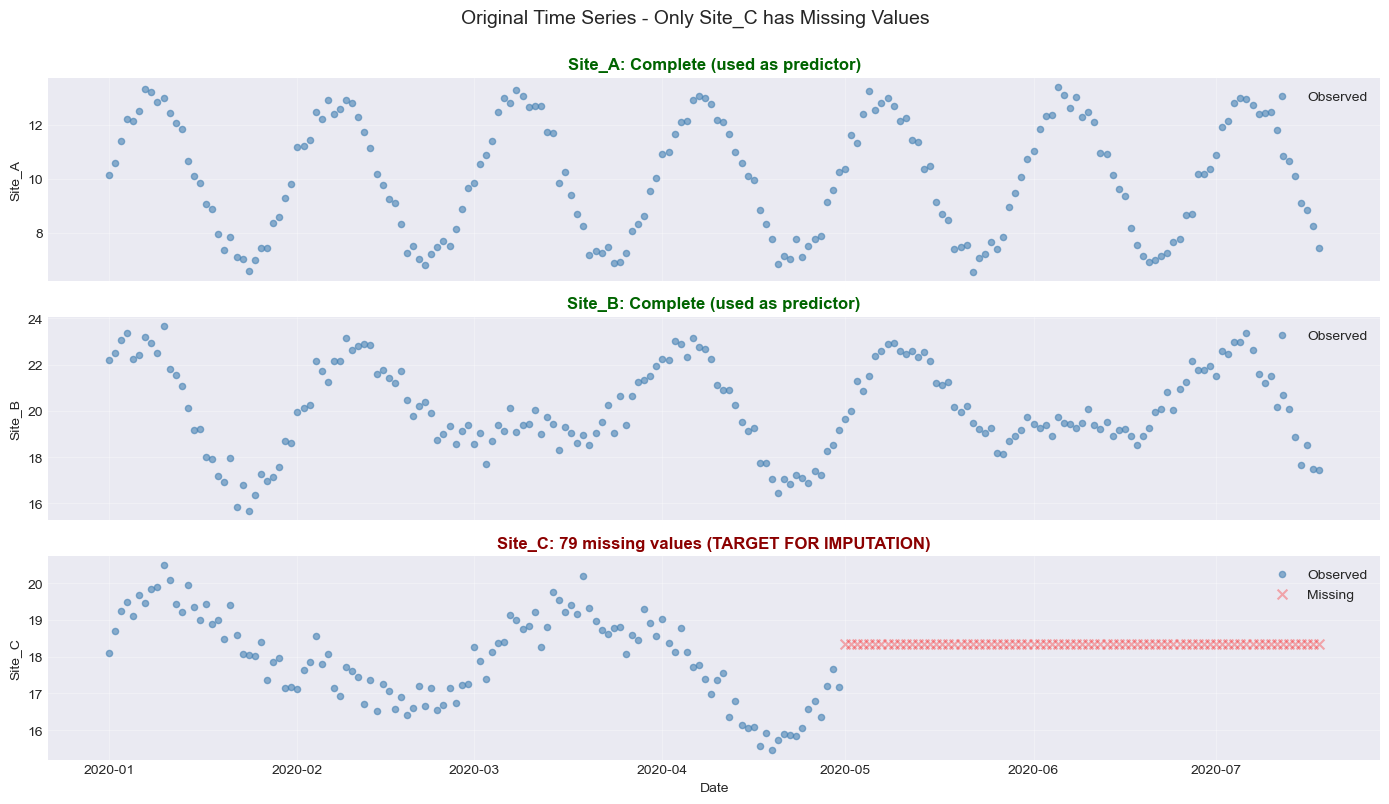

In [50]:
# Visualize the data with missing values
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, col in enumerate(df_complete.columns):
    ax = axes[i]
    
    # Plot observed values
    ax.scatter(df_complete.index, df_complete[col], 
              s=20, alpha=0.6, color='steelblue', label='Observed')
    
    # Highlight missing periods (only Site_C has missing values)
    missing_mask_col = df_complete[col].isna()
    if missing_mask_col.any():
        ax.scatter(df_complete.index[missing_mask_col], 
                  [df_truth.loc[df_complete.index[missing_mask_col], col].mean()] * missing_mask_col.sum(),
                  s=50, alpha=0.3, color='red', marker='x', label='Missing')
        ax.set_title(f'{col}: {df_complete[col].isna().sum()} missing values (TARGET FOR IMPUTATION)', 
                    fontweight='bold', color='darkred')
    else:
        ax.set_title(f'{col}: Complete (used as predictor)', fontweight='bold', color='darkgreen')
    
    ax.set_ylabel(col)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Original Time Series - Only Site_C has Missing Values', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 3. Method 1: Monte Carlo Uncertainty

**How it works:**
1. Temporarily mask some observed values
2. Impute the masked values
3. Compare imputed vs. actual (RMSE)
4. Repeat 100+ times → distribution of errors
5. Apply constant uncertainty band to all imputed values

**Pros:** Fast, realistic error estimate  
**Cons:** Constant band (same uncertainty everywhere)

In [51]:
# Perform imputation with Monte Carlo uncertainty
print("Running Monte Carlo uncertainty estimation...")
print("This masks observed values, imputes them, and measures error\n")

imputer_mc = Imputer(scaler=StandardScaler(), verbose=True)

df_imputed_mc, unc_mc = imputer_mc.fit_transform(
    df_complete,
    return_uncertainty=True,
    uncertainty_method='monte_carlo',
    n_repeats=100,
    mask_strategy='block',
    block_len=7,
    n_blocks=2,
    seed=42
)

# Get confidence intervals
df_lower_mc, df_upper_mc = imputer_mc.get_confidence_intervals(df_imputed_mc, unc_mc)

print(f"\n{'='*60}")
print(f"Monte Carlo Results:")
print(f"{'='*60}")
print(f"RMSE: {unc_mc['rmse']:.4f} ± {unc_mc['rmse_std']:.4f}")
print(f"MAE:  {unc_mc['mae']:.4f} ± {unc_mc['mae_std']:.4f}")
print(f"95% CI for RMSE: ({unc_mc['rmse_ci'][0]:.4f}, {unc_mc['rmse_ci'][1]:.4f})")
print(f"\nConstant uncertainty band: ±{unc_mc['rmse'] * 1.96:.4f}")

Running Monte Carlo uncertainty estimation...
This masks observed values, imputes them, and measures error

Estimated rank: 1 (variance threshold: 95%)
Imputing with rank=1, max_iters=500, tol=0.0001
Imputed 79 missing value(s)
Estimating uncertainty with 100 Monte Carlo repeats...
Strategy: block, Rank: 1
RMSE: 1.8113 (95% CI: 1.7525 - 1.8701)
MAE:  1.5551 (95% CI: 1.4956 - 1.6146)

Monte Carlo Results:
RMSE: 1.8113 ± 0.3001
MAE:  1.5551 ± 0.3034
95% CI for RMSE: (1.7525, 1.8701)

Constant uncertainty band: ±3.5501


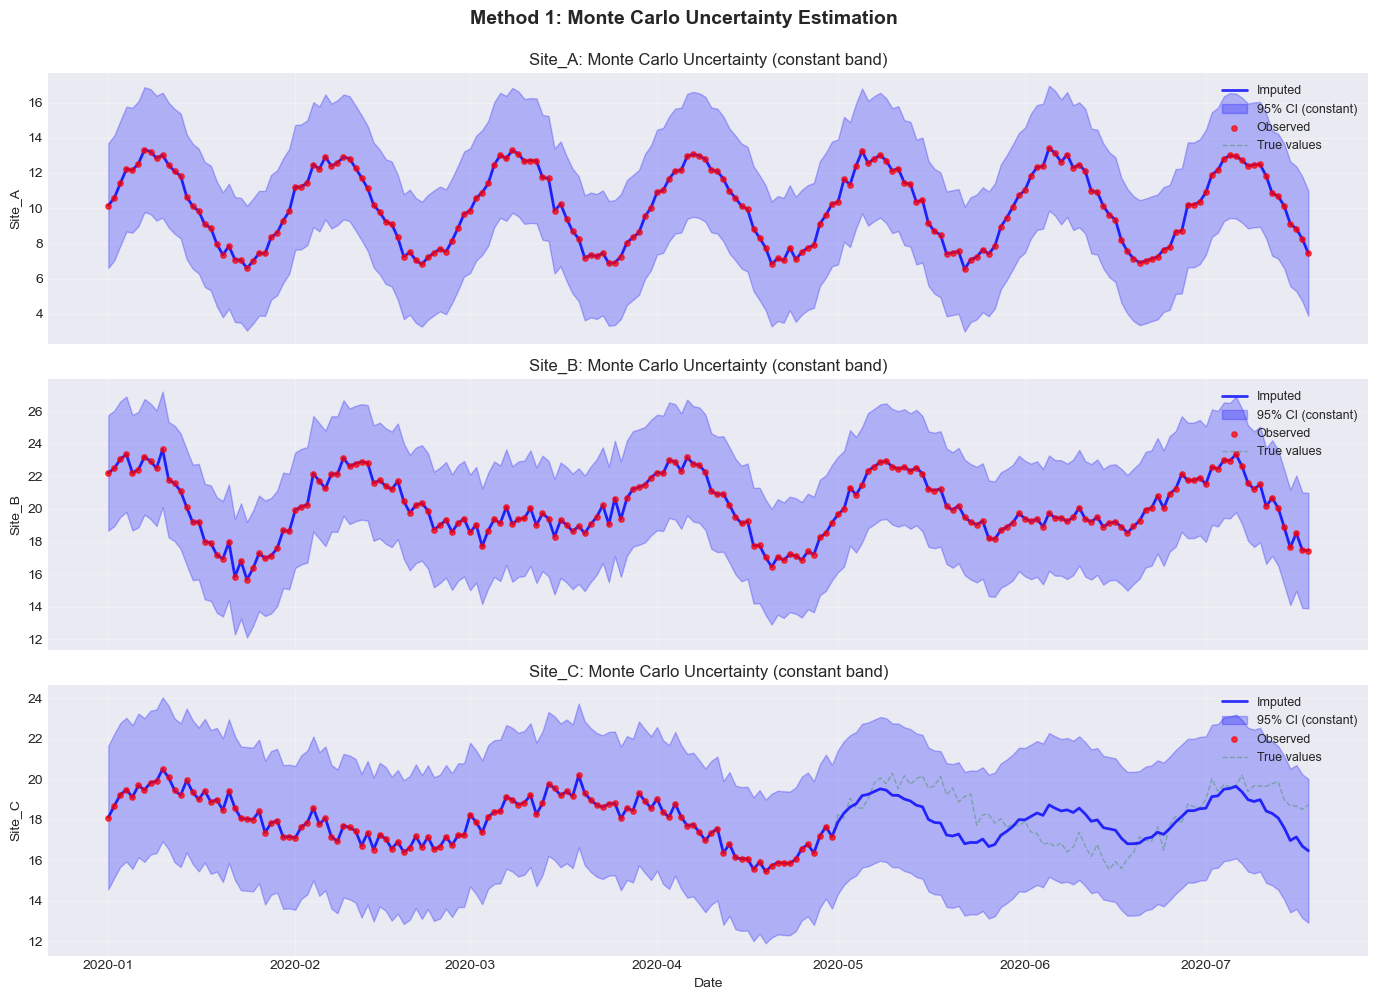


Actual MAE on imputed values: 0.9966
Predicted MAE from validation: 1.5551
Difference: 0.5586


In [52]:
# Visualize Monte Carlo results
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(df_imputed_mc.columns):
    ax = axes[i]
    
    # Plot imputed line
    ax.plot(df_imputed_mc.index, df_imputed_mc[col], 
           color='blue', linewidth=2, alpha=0.8, label='Imputed', zorder=3)
    
    # Plot uncertainty band (constant)
    ax.fill_between(df_imputed_mc.index, 
                   df_lower_mc[col], df_upper_mc[col],
                   alpha=0.25, color='blue', label='95% CI (constant)', zorder=1)
    
    # Plot observed values
    ax.scatter(df_complete.index, df_complete[col], 
              s=15, alpha=0.7, color='red', label='Observed', zorder=4)
    
    # Plot true values (for reference)
    ax.plot(df_truth.index, df_truth[col], 
           color='green', linewidth=1, alpha=0.3, linestyle='--', 
           label='True values', zorder=2)
    
    ax.set_ylabel(col)
    ax.set_title(f'{col}: Monte Carlo Uncertainty (constant band)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Method 1: Monte Carlo Uncertainty Estimation', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Calculate actual error on imputed values
missing_mask = df_complete.isna()
actual_errors_mc = np.abs(df_imputed_mc.values[missing_mask.values] - df_truth.values[missing_mask.values])
print(f"\nActual MAE on imputed values: {actual_errors_mc.mean():.4f}")
print(f"Predicted MAE from validation: {unc_mc['mae']:.4f}")
print(f"Difference: {abs(actual_errors_mc.mean() - unc_mc['mae']):.4f}")

## 4. Method 2: Bootstrap Uncertainty

**How it works:**
1. Resample observed values with replacement
2. Impute missing values on resampled data
3. Repeat 50+ times → distribution of predictions for each missing value
4. Compute percentiles → point-wise confidence intervals

**Pros:** Point-wise uncertainty, captures local variation  
**Cons:** Slower, may underestimate in sparse regions

In [53]:
# Perform imputation with Bootstrap uncertainty
print("Running Bootstrap uncertainty estimation...")
print("This resamples observed data and generates prediction distributions\n")

imputer_boot = Imputer(scaler=StandardScaler(), verbose=True)

df_imputed_boot, unc_boot = imputer_boot.fit_transform(
    df_complete,
    return_uncertainty=True,
    uncertainty_method='bootstrap',
    n_bootstrap=50,
    confidence=0.95,
    seed=42
)

# Get confidence intervals
df_lower_boot, df_upper_boot = imputer_boot.get_confidence_intervals(df_imputed_boot, unc_boot)

print(f"\n{'='*60}")
print(f"Bootstrap Results:")
print(f"{'='*60}")
print(f"Method: {unc_boot['method']}")
print(f"Confidence level: {unc_boot['confidence']}")

# Calculate average uncertainty width
ci_width = (df_upper_boot - df_lower_boot).values[missing_mask.values]
print(f"Average CI width: {ci_width.mean():.4f}")
print(f"Min CI width: {ci_width.min():.4f}")
print(f"Max CI width: {ci_width.max():.4f}")

# Average std for imputed values
std_imputed = unc_boot['std'].values[missing_mask.values]
print(f"\nAverage std of imputed values: {std_imputed.mean():.4f}")

Running Bootstrap uncertainty estimation...
This resamples observed data and generates prediction distributions

Estimated rank: 1 (variance threshold: 95%)
Imputing with rank=1, max_iters=500, tol=0.0001
Imputed 79 missing value(s)
Computing bootstrap uncertainty with 50 samples...


/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=6.17e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=1.40e-03). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=4.13e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=2.60e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (

Average uncertainty (std): 4.3402

Bootstrap Results:
Method: bootstrap
Confidence level: 0.95
Average CI width: 15.2363
Min CI width: 11.9148
Max CI width: 18.4008

Average std of imputed values: 4.3402


/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=3.71e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=2.20e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=1.10e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=4.90e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (

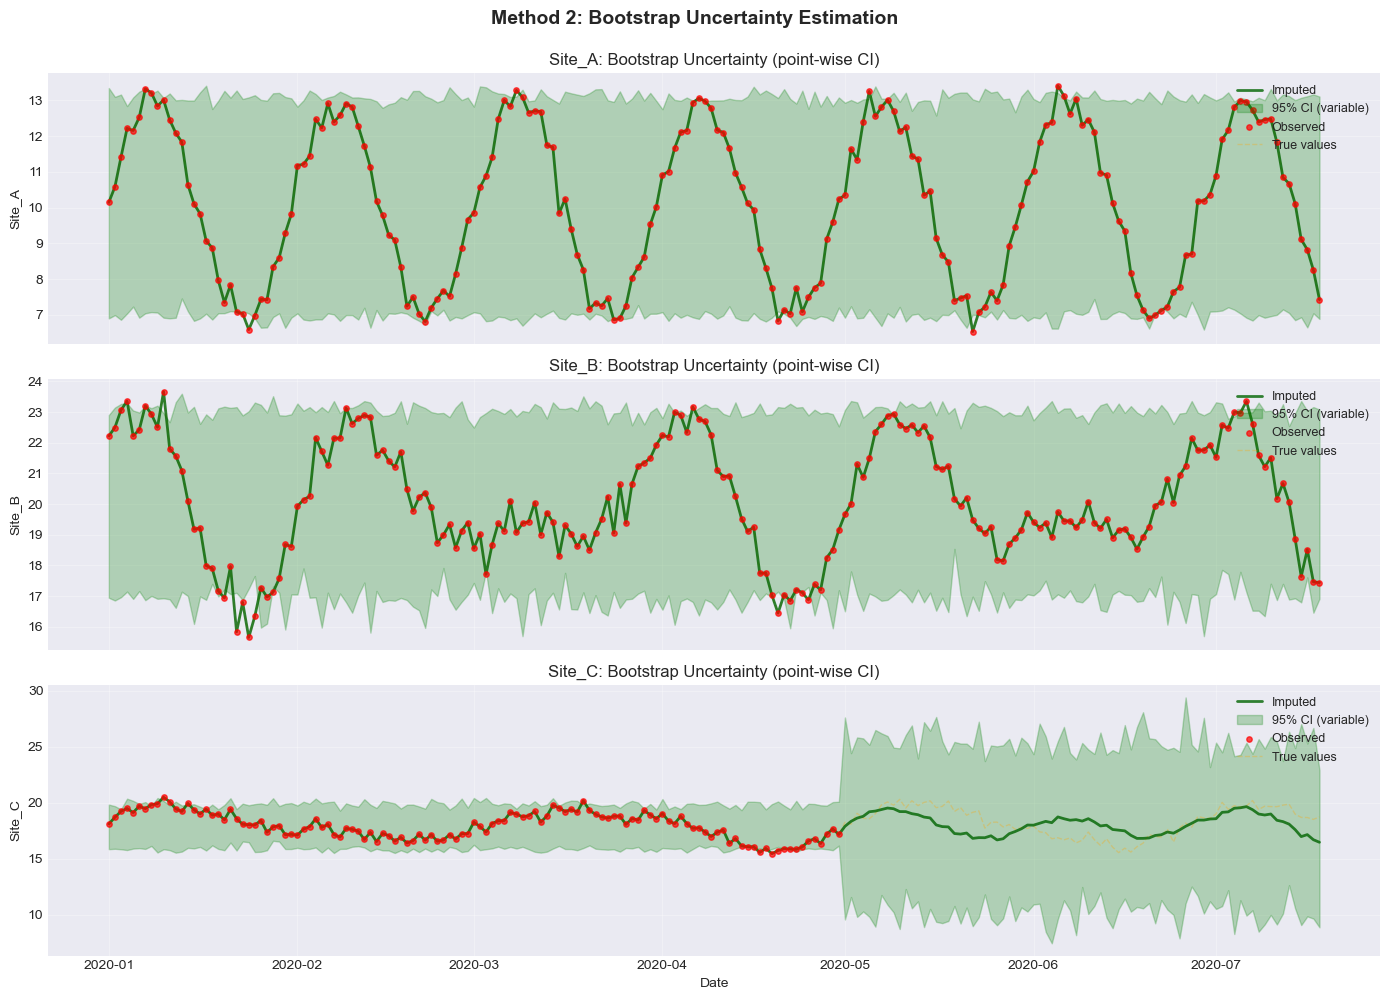


Actual MAE on imputed values: 0.9966


In [54]:
# Visualize Bootstrap results
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(df_imputed_boot.columns):
    ax = axes[i]
    
    # Plot imputed line
    ax.plot(df_imputed_boot.index, df_imputed_boot[col], 
           color='darkgreen', linewidth=2, alpha=0.8, label='Imputed', zorder=3)
    
    # Plot uncertainty band (variable - point-wise)
    ax.fill_between(df_imputed_boot.index, 
                   df_lower_boot[col], df_upper_boot[col],
                   alpha=0.25, color='green', label='95% CI (variable)', zorder=1)
    
    # Plot observed values
    ax.scatter(df_complete.index, df_complete[col], 
              s=15, alpha=0.7, color='red', label='Observed', zorder=4)
    
    # Plot true values
    ax.plot(df_truth.index, df_truth[col], 
           color='orange', linewidth=1, alpha=0.3, linestyle='--', 
           label='True values', zorder=2)
    
    ax.set_ylabel(col)
    ax.set_title(f'{col}: Bootstrap Uncertainty (point-wise CI)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Method 2: Bootstrap Uncertainty Estimation', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Calculate actual error
actual_errors_boot = np.abs(df_imputed_boot.values[missing_mask.values] - df_truth.values[missing_mask.values])
print(f"\nActual MAE on imputed values: {actual_errors_boot.mean():.4f}")

## 5. Method 3: Hybrid Uncertainty

**How it works:**
1. Run Monte Carlo validation → overall RMSE
2. Run Bootstrap → point-wise variation
3. Scale Bootstrap intervals by MC RMSE ratio
4. Return calibrated point-wise intervals

**Pros:** Best accuracy, realistic + local  
**Cons:** Slowest (combines both methods)

In [55]:
# Perform imputation with Hybrid uncertainty
print("Running Hybrid uncertainty estimation...")
print("This combines Monte Carlo validation with Bootstrap resampling\n")

imputer_hybrid = Imputer(scaler=StandardScaler(), verbose=True)

df_imputed_hybrid, unc_hybrid = imputer_hybrid.fit_transform(
    df_complete,
    return_uncertainty=True,
    uncertainty_method='hybrid',
    n_repeats=50,
    n_bootstrap=30,
    mask_strategy='block',
    block_len=7,
    confidence=0.95,
    seed=42
)

# Get confidence intervals
df_lower_hybrid, df_upper_hybrid = imputer_hybrid.get_confidence_intervals(df_imputed_hybrid, unc_hybrid)

print(f"\n{'='*60}")
print(f"Hybrid Results:")
print(f"{'='*60}")
print(f"Method: {unc_hybrid['method']}")
print(f"Monte Carlo RMSE: {unc_hybrid['monte_carlo']['rmse']:.4f}")

# Calculate average uncertainty width
ci_width_hybrid = (df_upper_hybrid - df_lower_hybrid).values[missing_mask.values]
print(f"Average CI width: {ci_width_hybrid.mean():.4f}")
print(f"Min CI width: {ci_width_hybrid.min():.4f}")
print(f"Max CI width: {ci_width_hybrid.max():.4f}")

Running Hybrid uncertainty estimation...
This combines Monte Carlo validation with Bootstrap resampling

Estimated rank: 1 (variance threshold: 95%)
Imputing with rank=1, max_iters=500, tol=0.0001
Imputed 79 missing value(s)
Computing hybrid uncertainty...
Estimating uncertainty with 50 Monte Carlo repeats...
Strategy: block, Rank: 1
RMSE: 1.7576 (95% CI: 1.6713 - 1.8440)
MAE:  1.5020 (95% CI: 1.4161 - 1.5879)
Computing bootstrap uncertainty with 30 samples...


/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=6.17e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=1.40e-03). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=4.13e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=2.60e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (

Average uncertainty (std): 4.3872

Hybrid Results:
Method: hybrid
Monte Carlo RMSE: 1.7576
Average CI width: 6.8899
Min CI width: 5.1226
Max CI width: 8.8629


/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=2.97e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=1.21e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=2.45e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (diff=6.23e-04). Consider increasing max_iters or relaxing tol.
  warnings.warn(
/Users/ruihugman/GitHub/ranger.svdtseries/svd_imputer/imputer.py:174: RuntimeWarning: Max iterations (500) reached without convergence (

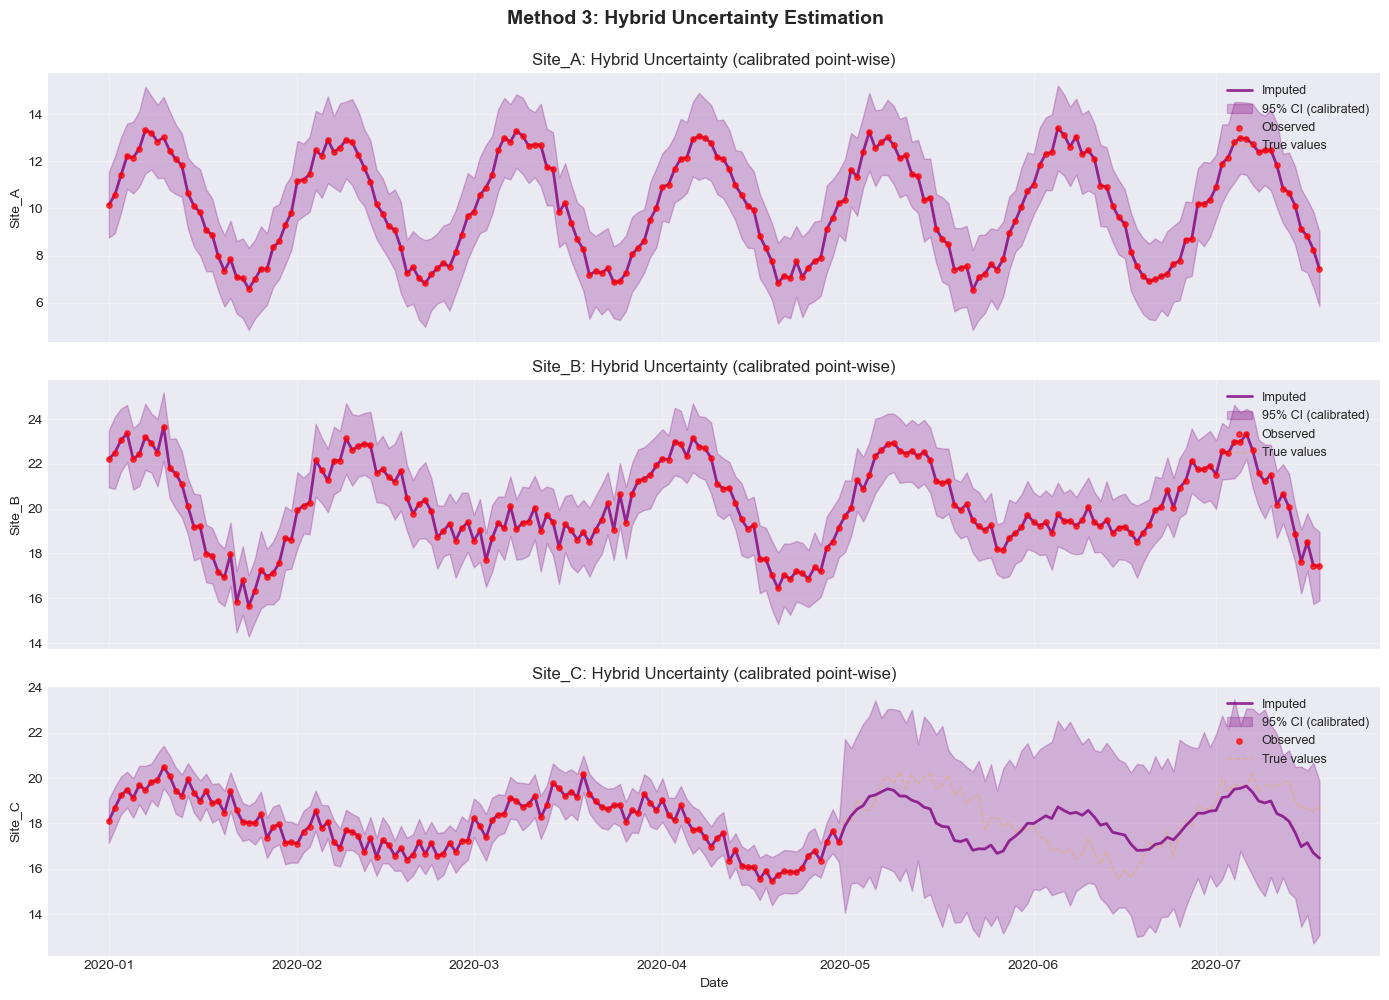


Actual MAE on imputed values: 0.9966


In [56]:
# Visualize Hybrid results
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(df_imputed_hybrid.columns):
    ax = axes[i]
    
    # Plot imputed line
    ax.plot(df_imputed_hybrid.index, df_imputed_hybrid[col], 
           color='purple', linewidth=2, alpha=0.8, label='Imputed', zorder=3)
    
    # Plot uncertainty band (calibrated point-wise)
    ax.fill_between(df_imputed_hybrid.index, 
                   df_lower_hybrid[col], df_upper_hybrid[col],
                   alpha=0.25, color='purple', label='95% CI (calibrated)', zorder=1)
    
    # Plot observed values
    ax.scatter(df_complete.index, df_complete[col], 
              s=15, alpha=0.7, color='red', label='Observed', zorder=4)
    
    # Plot true values
    ax.plot(df_truth.index, df_truth[col], 
           color='orange', linewidth=1, alpha=0.3, linestyle='--', 
           label='True values', zorder=2)
    
    ax.set_ylabel(col)
    ax.set_title(f'{col}: Hybrid Uncertainty (calibrated point-wise)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Method 3: Hybrid Uncertainty Estimation', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Calculate actual error
actual_errors_hybrid = np.abs(df_imputed_hybrid.values[missing_mask.values] - df_truth.values[missing_mask.values])
print(f"\nActual MAE on imputed values: {actual_errors_hybrid.mean():.4f}")

## 6. Side-by-Side Comparison

Let's compare all three methods visually for Site_C (the only site with missing values) to see the differences in uncertainty bands.

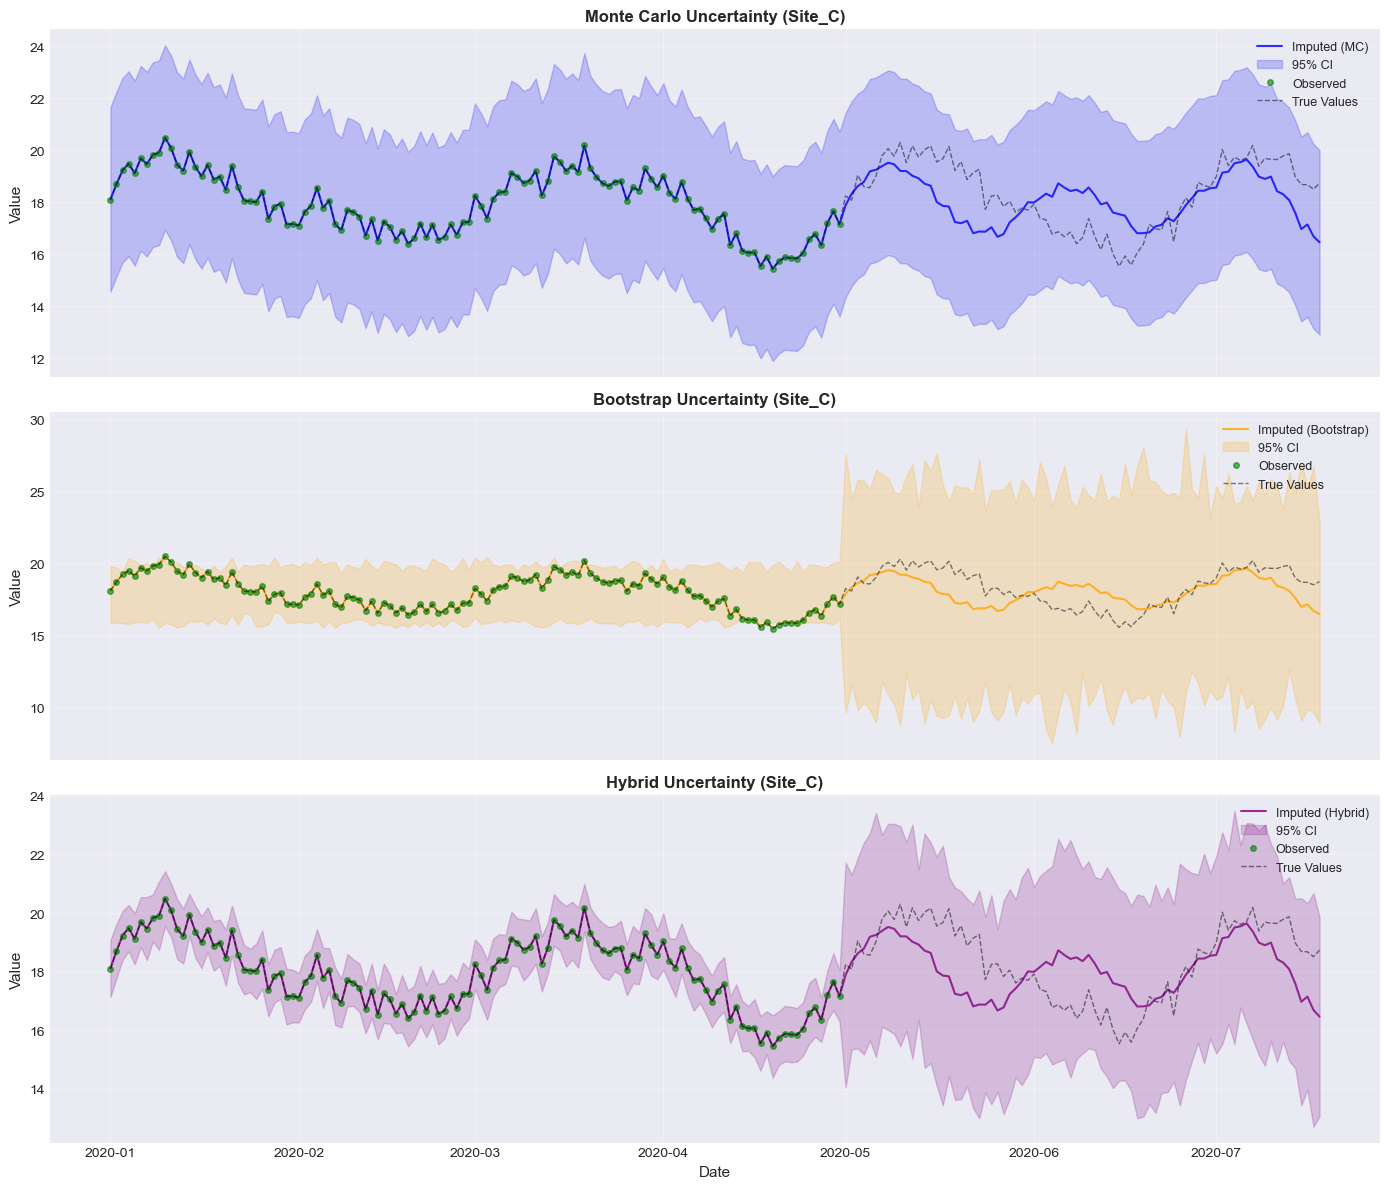

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
series_idx = 2  # Site_C (the only series with missing values)

# Monte Carlo
ax = axes[0]
ax.plot(df_complete.index, df_imputed_mc.iloc[:, series_idx], 
        'b-', linewidth=1.5, label='Imputed (MC)', alpha=0.8)
ax.fill_between(df_complete.index, 
                df_lower_mc.iloc[:, series_idx], 
                df_upper_mc.iloc[:, series_idx],
                color='blue', alpha=0.2, label='95% CI')
ax.plot(df_complete.index, df_complete.iloc[:, series_idx], 
        'go', markersize=4, label='Observed', alpha=0.6)
ax.plot(df_complete.index, df_truth.iloc[:, series_idx], 
        'k--', linewidth=1, label='True Values', alpha=0.5)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Monte Carlo Uncertainty (Site_C)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Bootstrap
ax = axes[1]
ax.plot(df_complete.index, df_imputed_boot.iloc[:, series_idx], 
        'orange', linewidth=1.5, label='Imputed (Bootstrap)', alpha=0.8)
ax.fill_between(df_complete.index, 
                df_lower_boot.iloc[:, series_idx], 
                df_upper_boot.iloc[:, series_idx],
                color='orange', alpha=0.2, label='95% CI')
ax.plot(df_complete.index, df_complete.iloc[:, series_idx], 
        'go', markersize=4, label='Observed', alpha=0.6)
ax.plot(df_complete.index, df_truth.iloc[:, series_idx], 
        'k--', linewidth=1, label='True Values', alpha=0.5)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Bootstrap Uncertainty (Site_C)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Hybrid
ax = axes[2]
ax.plot(df_complete.index, df_imputed_hybrid.iloc[:, series_idx], 
        'purple', linewidth=1.5, label='Imputed (Hybrid)', alpha=0.8)
ax.fill_between(df_complete.index, 
                df_lower_hybrid.iloc[:, series_idx], 
                df_upper_hybrid.iloc[:, series_idx],
                color='purple', alpha=0.2, label='95% CI')
ax.plot(df_complete.index, df_complete.iloc[:, series_idx], 
        'go', markersize=4, label='Observed', alpha=0.6)
ax.plot(df_complete.index, df_truth.iloc[:, series_idx], 
        'k--', linewidth=1, label='True Values', alpha=0.5)
ax.set_ylabel('Value', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Hybrid Uncertainty (Site_C)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Quantitative Comparison

Now let's quantify the differences between the three methods in terms of uncertainty band width, computation time, and coverage.

In [58]:
import time

# Calculate average CI width for missing values only
missing_mask = df_complete.isna()

ci_widths_mc = (df_upper_mc - df_lower_mc)[missing_mask].mean().mean()
ci_widths_bs = (df_upper_boot - df_lower_boot)[missing_mask].mean().mean()
ci_widths_hybrid = (df_upper_hybrid - df_lower_hybrid)[missing_mask].mean().mean()

# Calculate RMSE for missing values (filter out any remaining NaN)
from sklearn.metrics import mean_squared_error

# Get values where data was originally missing
truth_vals_mc = df_truth[missing_mask].values.ravel()
imputed_vals_mc = df_imputed_mc[missing_mask].values.ravel()
valid_mc = ~np.isnan(truth_vals_mc) & ~np.isnan(imputed_vals_mc)

truth_vals_bs = df_truth[missing_mask].values.ravel()
imputed_vals_bs = df_imputed_boot[missing_mask].values.ravel()
valid_bs = ~np.isnan(truth_vals_bs) & ~np.isnan(imputed_vals_bs)

truth_vals_hybrid = df_truth[missing_mask].values.ravel()
imputed_vals_hybrid = df_imputed_hybrid[missing_mask].values.ravel()
valid_hybrid = ~np.isnan(truth_vals_hybrid) & ~np.isnan(imputed_vals_hybrid)

rmse_mc = np.sqrt(mean_squared_error(truth_vals_mc[valid_mc], imputed_vals_mc[valid_mc]))
rmse_bs = np.sqrt(mean_squared_error(truth_vals_bs[valid_bs], imputed_vals_bs[valid_bs]))
rmse_hybrid = np.sqrt(mean_squared_error(truth_vals_hybrid[valid_hybrid], imputed_vals_hybrid[valid_hybrid]))

# Calculate coverage (% of true values within CI)
def calculate_coverage(true_vals, lower_ci, upper_ci, mask):
    true_masked = true_vals[mask].values.ravel()
    lower_masked = lower_ci[mask].values.ravel()
    upper_masked = upper_ci[mask].values.ravel()
    
    # Filter out any NaN values
    valid = ~np.isnan(true_masked) & ~np.isnan(lower_masked) & ~np.isnan(upper_masked)
    true_masked = true_masked[valid]
    lower_masked = lower_masked[valid]
    upper_masked = upper_masked[valid]
    
    within_ci = ((true_masked >= lower_masked) & (true_masked <= upper_masked)).sum()
    return 100 * within_ci / len(true_masked)

coverage_mc = calculate_coverage(df_truth, df_lower_mc, df_upper_mc, missing_mask)
coverage_bs = calculate_coverage(df_truth, df_lower_boot, df_upper_boot, missing_mask)
coverage_hybrid = calculate_coverage(df_truth, df_lower_hybrid, df_upper_hybrid, missing_mask)

# Print comparison table
print("=" * 70)
print(f"{'Method':<15} {'Avg CI Width':<15} {'RMSE':<12} {'Coverage (%)':<15}")
print("=" * 70)
print(f"{'Monte Carlo':<15} {ci_widths_mc:<15.3f} {rmse_mc:<12.3f} {coverage_mc:<15.1f}")
print(f"{'Bootstrap':<15} {ci_widths_bs:<15.3f} {rmse_bs:<12.3f} {coverage_bs:<15.1f}")
print(f"{'Hybrid':<15} {ci_widths_hybrid:<15.3f} {rmse_hybrid:<12.3f} {coverage_hybrid:<15.1f}")
print("=" * 70)
print("\nNote: Ideal coverage for 95% CI is 95%")
print("Note: Narrower CI width is better if coverage is maintained")

Method          Avg CI Width    RMSE         Coverage (%)   
Monte Carlo     7.100           1.217        100.0          
Bootstrap       15.236          1.217        100.0          
Hybrid          6.890           1.217        100.0          

Note: Ideal coverage for 95% CI is 95%
Note: Narrower CI width is better if coverage is maintained


## 8. Uncertainty Band Width Heatmap

Visualize how uncertainty varies across time and series for each method.

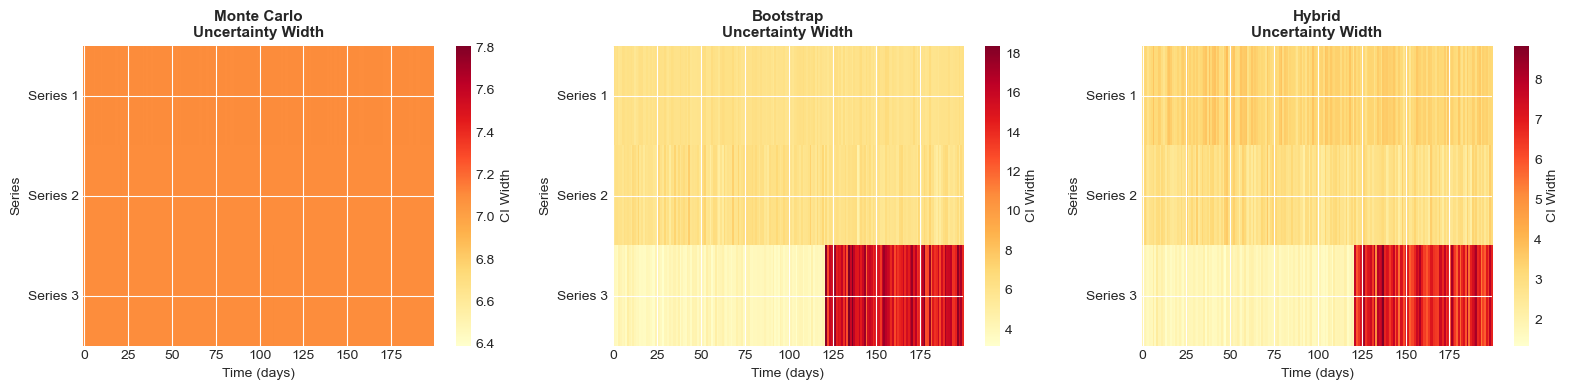

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Calculate CI widths
ci_width_mc = df_upper_mc - df_lower_mc
ci_width_bs = df_upper_boot - df_lower_boot
ci_width_hybrid = df_upper_hybrid - df_lower_hybrid

# Monte Carlo heatmap
im1 = axes[0].imshow(ci_width_mc.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[0].set_xlabel('Time (days)', fontsize=10)
axes[0].set_ylabel('Series', fontsize=10)
axes[0].set_title('Monte Carlo\nUncertainty Width', fontsize=11, fontweight='bold')
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(['Series 1', 'Series 2', 'Series 3'])
plt.colorbar(im1, ax=axes[0], label='CI Width')

# Bootstrap heatmap
im2 = axes[1].imshow(ci_width_bs.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[1].set_xlabel('Time (days)', fontsize=10)
axes[1].set_ylabel('Series', fontsize=10)
axes[1].set_title('Bootstrap\nUncertainty Width', fontsize=11, fontweight='bold')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Series 1', 'Series 2', 'Series 3'])
plt.colorbar(im2, ax=axes[1], label='CI Width')

# Hybrid heatmap
im3 = axes[2].imshow(ci_width_hybrid.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[2].set_xlabel('Time (days)', fontsize=10)
axes[2].set_ylabel('Series', fontsize=10)
axes[2].set_title('Hybrid\nUncertainty Width', fontsize=11, fontweight='bold')
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(['Series 1', 'Series 2', 'Series 3'])
plt.colorbar(im3, ax=axes[2], label='CI Width')

plt.tight_layout()
plt.show()

## 9. Key Differences and Recommendations

### Summary of Uncertainty Methods

**Monte Carlo Uncertainty:**
- **Approach**: Masks random observed values, measures global RMSE, applies constant band
- **Pros**: Fast, simple, provides conservative estimate
- **Cons**: Constant width doesn't capture local variation
- **Best for**: Quick analysis, when computational resources are limited

**Bootstrap Uncertainty:**
- **Approach**: Resamples observed data many times, measures point-wise variation
- **Pros**: Captures local uncertainty variation, theoretically sound
- **Cons**: More computationally intensive, requires sufficient observed data
- **Best for**: When you need detailed point-wise confidence intervals

**Hybrid Uncertainty:**
- **Approach**: Combines Monte Carlo validation with Bootstrap variation
- **Pros**: Balances global accuracy with local variation, well-calibrated
- **Cons**: Most computationally expensive
- **Best for**: Critical applications requiring both accuracy and precision

### Decision Guide

Choose your uncertainty method based on:

1. **Computation time vs accuracy trade-off**
   - Fast: Monte Carlo (~100 repeats)
   - Medium: Bootstrap (~50 bootstraps)
   - Slow: Hybrid (~50 MC × 30 bootstraps)

2. **Data characteristics**
   - Sparse data → Monte Carlo (more robust)
   - Dense data → Bootstrap or Hybrid (better local estimates)

3. **Application requirements**
   - Exploratory analysis → Monte Carlo
   - Publication/reporting → Bootstrap or Hybrid
   - Critical decisions → Hybrid (best calibrated)

## 10. Conclusion

This notebook demonstrated three different approaches to uncertainty quantification in time series imputation using SVD:

1. **Monte Carlo**: Provides global validation-based uncertainty estimates
2. **Bootstrap**: Captures point-wise uncertainty through resampling
3. **Hybrid**: Combines both approaches for calibrated confidence intervals

All three methods are available through the `svd_imputer` package with a simple `uncertainty_method` parameter.

### Next Steps

- Try these methods on your own data
- Experiment with different `n_repeats` and `n_bootstrap` values
- Compare coverage rates on validation datasets
- Consider ensemble approaches combining multiple methods

For more details, see the [UNCERTAINTY_GUIDE.md](UNCERTAINTY_GUIDE.md) documentation.